In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [8]:
img_height = 128
img_width = 128
batch_size = 32

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "Data/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    "Data/val",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 5600 images belonging to 5 classes.
Found 400 images belonging to 5 classes.


In [37]:
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(train_data.num_classes, activation='softmax'))

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]

In [40]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 58s 324ms/step - accuracy: 0.4420 - loss: 1.2945 - val_accuracy: 0.4825 - val_loss: 1.2298
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.5398 - loss: 1.1164 - val_accuracy: 0.4975 - val_loss: 1.1900
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 62s 356ms/step - accuracy: 0.5745 - loss: 1.0420 - val_accuracy: 0.4925 - val_loss: 1.0998
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 60s 342ms/step - accuracy: 0.5984 - loss: 0.9964 - val_accuracy: 0.5025 - val_loss: 1.1158
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 56s 321ms/step - accuracy: 0.6127 - loss: 0.9736 - val_accuracy: 0.5425 - val_loss: 1.0884
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 56s 322ms/step - accuracy: 0.6209 - loss: 0.9498 - val_accuracy: 0.5300 - val_loss: 1.0810
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 57s 323ms/step - accuracy: 0.6359 - loss: 0.9094 - val_accuracy: 0.5475 - val_loss: 1.0956
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 56s 321ms/step - accuracy: 0.6495 - loss: 0

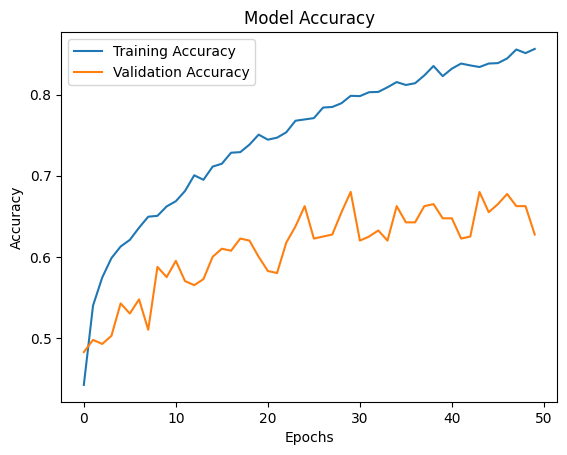

In [41]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

In [2]:
model.save("CNN_MODEL_FRUIT_CLASSIFICATION.h5")

NameError: name 'model' is not defined

In [43]:
import json
with open("Trained_History_PROJECT_FRUIT.json",'w') as f:
    json.dump(history.history,f)

In [80]:
test_data = train_datagen.flow_from_directory(
    "test",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False   # important for evaluation
)

_,acc = model.evaluate(test_data)
print(acc*100)

Found 100 images belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8500 - loss: 0.4475
85.00000238418579


In [84]:
from tensorflow.keras.preprocessing import image

img = image.load_img(r"test\Strawberry\Image_30.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)
class_index = np.argmax(prediction)

class_labels = list(train_data.class_indices.keys())
print("Predicted Fruit:", class_labels[class_index])
print("Confidance Level:", img_array[class_index]*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Fruit: Strawberry


IndexError: index 4 is out of bounds for axis 0 with size 1

In [5]:
model = tf.keras.models.load_model("CNN_MODEL_FRUIT_CLASSIFICATION.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


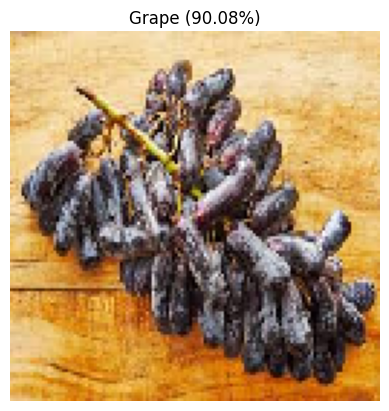

In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
img = image.load_img(r"image.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Get predicted class index
class_index = np.argmax(prediction)

# Map to class labels
class_labels = list(train_data.class_indices.keys())
predicted_class = class_labels[class_index]

# Get confidence for the predicted class
confidence = prediction[0][class_index] * 100


plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()